**24BAD405 - NISHANTH P**

### 1. Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### 2. Load the Iris Dataset

In [3]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Convert to DataFrame for easier inspection
df = pd.DataFrame(X, columns=feature_names)
df['species'] = y
df['species_name'] = df['species'].apply(lambda x: target_names[x])

print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### 3. Data Inspection & Preprocessing

In [4]:
print("Dataset Shape:", df.shape)
print("\nMissing Values Check:")
print(df.isnull().sum())
print("\nData Statistics:")
df.describe()

Dataset Shape: (150, 6)

Missing Values Check:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

Data Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### 4. Split Dataset and Apply Feature Scaling

In [5]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 120
Testing set size: 30


### 5. Train Gaussian Naive Bayes Classifier

In [6]:
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

,priors,None
,var_smoothing,1e-09


### 6. Predict and Evaluate Performance

In [7]:
y_pred = gnb.predict(X_test_scaled)

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

# Compare predictions with actual labels
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
results_df['Actual_Name'] = results_df['Actual'].apply(lambda x: target_names[x])
results_df['Predicted_Name'] = results_df['Predicted'].apply(lambda x: target_names[x])
display(results_df.head(10))

Accuracy Score: 1.0

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



,Actual,Predicted,Actual_Name,Predicted_Name
0,1,1,versicolor,versicolor
1,0,0,setosa,setosa
2,2,2,virginica,virginica
3,1,1,versicolor,versicolor
4,1,1,versicolor,versicolor
5,0,0,setosa,setosa
6,1,1,versicolor,versicolor
7,2,2,virginica,virginica
8,1,1,versicolor,versicolor
9,1,1,versicolor,versicolor


### 7. Analyze Class Probabilities

In [8]:
probs = gnb.predict_proba(X_test_scaled)
probs_df = pd.DataFrame(probs, columns=target_names)
probs_df['Predicted_Class'] = results_df['Predicted_Name']
display(probs_df.head(10))

,setosa,versicolor,virginica,Predicted_Class
0,5.973218e-90,9.956358e-01,4.364232e-03,versicolor
1,1.000000e+00,4.961577e-14,6.549219e-21,setosa
2,7.318581e-290,4.929473e-12,1.000000e+00,virginica
3,2.818380e-94,9.775936e-01,2.240644e-02,versicolor
4,1.138762e-105,8.700226e-01,1.299774e-01,versicolor
5,1.000000e+00,1.731801e-13,3.661700e-21,setosa
6,5.904304e-53,9.999556e-01,4.435500e-05,versicolor
7,5.987089e-177,1.182198e-06,9.999988e-01,virginica
8,4.017460e-96,9.921583e-01,7.841723e-03,versicolor
9,3.150688e-59,9.999390e-01,6.101718e-05,versicolor


### 8. Visualization: Confusion Matrix

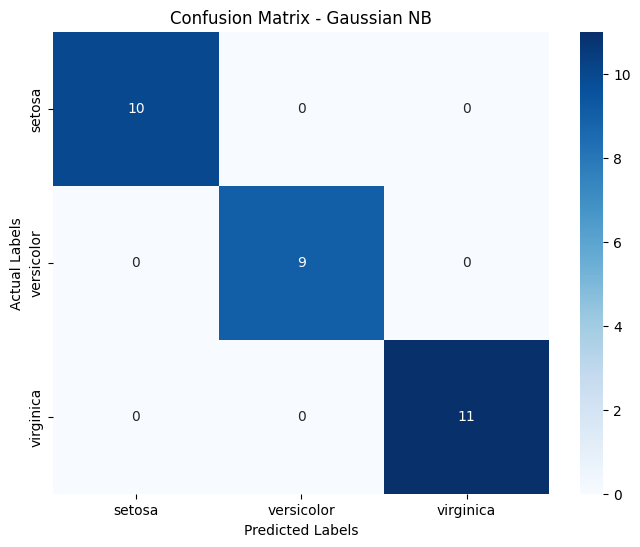

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("Confusion Matrix - Gaussian NB")
plt.show()

### 9. Visualization: Probability Distribution

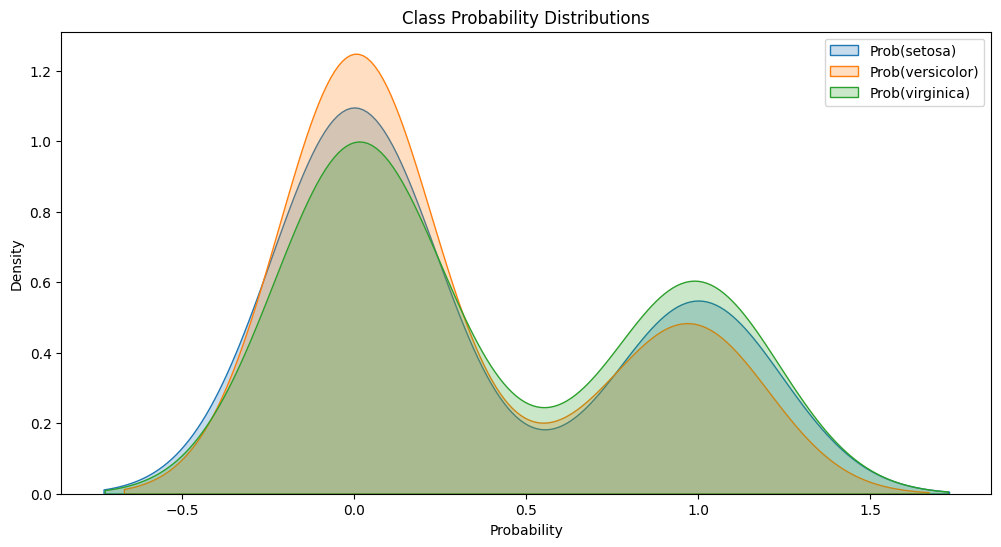

In [10]:
plt.figure(figsize=(12, 6))
for i, class_name in enumerate(target_names):
    sns.kdeplot(probs[:, i], label=f'Prob({class_name})', fill=True)
plt.title("Class Probability Distributions")
plt.xlabel("Probability")
plt.ylabel("Density")
plt.legend()
plt.show()

### 10. Visualization: Decision Boundary (using first two features)

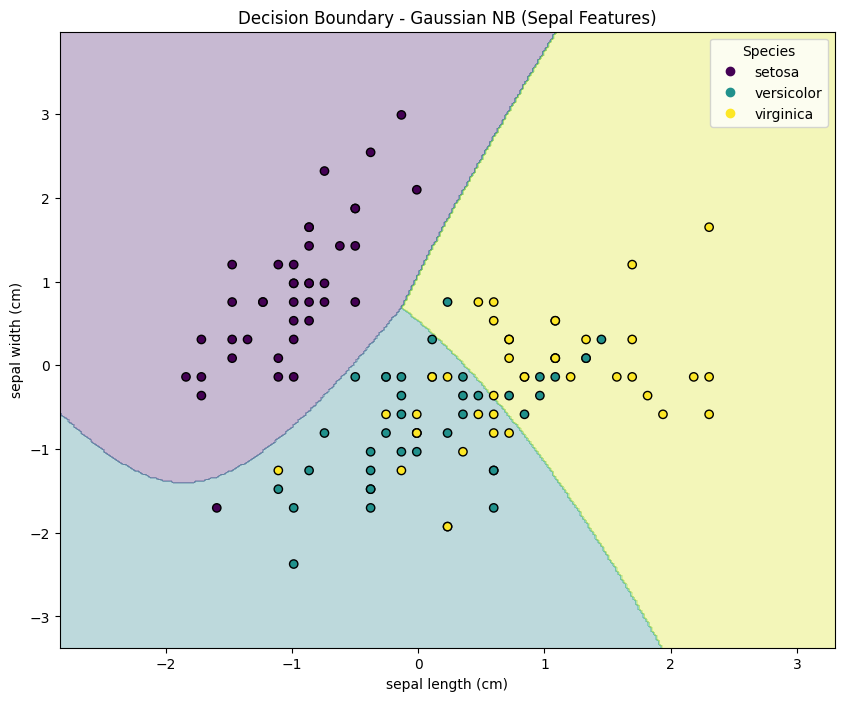

In [11]:
def plot_decision_boundary(model, X, y, feature_names, target_names):
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    # We train the model on just the first two features for visualization
    model_2d = GaussianNB()
    model_2d.fit(X[:, :2], y)
    Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k')
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title("Decision Boundary - Gaussian NB (Sepal Features)")
    
    # Add legend
    handles, _ = scatter.legend_elements()
    plt.legend(handles, target_names, title="Species")
    plt.show()

plot_decision_boundary(gnb, X_train_scaled, y_train, feature_names, target_names)

### 11. Compare Gaussian NB with Logistic Regression

In [12]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("\nGaussian NB Accuracy:", accuracy_score(y_test, y_pred))

if accuracy_score(y_test, y_pred) >= accuracy_score(y_test, lr_pred):
    print("\nGaussian Naive Bayes performed as well as or better than Logistic Regression on this test set.")
else:
    print("\nLogistic Regression performed better than Gaussian Naive Bayes on this test set.")

Logistic Regression Accuracy: 1.0

Gaussian NB Accuracy: 1.0

Gaussian Naive Bayes performed as well as or better than Logistic Regression on this test set.
